In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_curve, roc_auc_score
from scipy.stats import mannwhitneyu
import joblib
import os

class ModalityFusionTransformer(nn.Module):
    def __init__(self, omics_dim, text_dim, dim, depth, heads, dropout):
        super().__init__()
        self.omics_dim = omics_dim
        self.text_dim = text_dim
        
        self.omics_embedding = nn.Linear(omics_dim, dim)
        self.text_embedding = nn.Linear(text_dim, dim)
        
        self.omics_cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.text_cls_token = nn.Parameter(torch.randn(1, 1, dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=dim * 4, 
            dropout=dropout, activation='relu', batch_first=True
        )
        self.omics_transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.text_transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.alpha = nn.Parameter(torch.tensor(0.5))

        self.output_layer = nn.Sequential(
            nn.LayerNorm(dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x, label=None):
        omics_x = x[:, :self.omics_dim]
        text_x = x[:, self.omics_dim:]
        
        omics_embedded = self.omics_embedding(omics_x).unsqueeze(1)
        text_embedded = self.text_embedding(text_x).unsqueeze(1)

        b = omics_embedded.shape[0]
        omics_cls_tokens = self.omics_cls_token.repeat(b, 1, 1)
        omics_input = torch.cat((omics_cls_tokens, omics_embedded), dim=1)
        omics_encoded = self.omics_transformer(omics_input)
        omics_repr = omics_encoded[:, 0]

        fused_text_embedded = text_embedded + omics_encoded[:, 1].unsqueeze(1)

        text_cls_tokens = self.text_cls_token.repeat(b, 1, 1)
        text_input = torch.cat((text_cls_tokens, fused_text_embedded), dim=1)
        text_encoded = self.text_transformer(text_input)
        text_repr = text_encoded[:, 0]

        alpha_sigmoid = torch.sigmoid(self.alpha) 
        fused_repr = alpha_sigmoid * omics_repr + (1 - alpha_sigmoid) * text_repr

        logit = self.output_layer(fused_repr)
        
        loss = None
        if label is not None:
            loss = F.binary_cross_entropy(logit.view(-1), label.float().view(-1))

        return logit, loss, alpha_sigmoid.item()

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def run_schizophrenia_gene_cv(
    pos_file,
    neg_file,
    k=5,
    model_save_path="./save/druggable_gene/schizophrenia_model", 
    scaler_save_path="./save/druggable_gene/schizophrenia_model/best_scaler.pkl",
):
    os.makedirs(model_save_path, exist_ok=True)
    

    df_pos = pd.read_csv(pos_file, index_col=0)
    df_neg = pd.read_csv(neg_file, index_col=0)
    df_all = pd.concat([df_pos, df_neg], axis=0)
    df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_all.fillna(0, inplace=True)
    
    data = df_all.values.astype(np.float32)
    labels = np.concatenate([np.ones(len(df_pos)), np.zeros(len(df_neg))])
    
    skf = StratifiedKFold(n_splits=k, shuffle=False)  
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    aucs, prs, alphas = [], [], []
    best_fold_auc = 0
    final_best_threshold = 0.5 

    for fold, (train_index, test_index) in enumerate(skf.split(data, labels)):
        print(f"\n--- Fold {fold+1}/{k} ---")
        X_train, X_test = data[train_index], data[test_index]
        y_train, y_test = labels[train_index], labels[test_index]
        
        scaler = MaxAbsScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        set_seed(fold)
        model = ModalityFusionTransformer(omics_dim=18, text_dim=768, dim=64, depth=8, heads=8, dropout=0.2)
        model.to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
        
        for epoch in range(10):
            model.train()
            fold_alphas = []
            for batch_data, batch_labels in train_loader:
                batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
                optimizer.zero_grad()
                _, loss, alpha = model(batch_data, batch_labels)
                loss.backward()
                optimizer.step()
                fold_alphas.append(alpha)
        
        alphas.append(np.mean(fold_alphas))

        model.eval()
        with torch.no_grad():
            probas, _, _ = model(X_test_tensor.to(device), y_test_tensor.to(device))
            probas = probas.cpu().numpy().flatten()
            
        fold_auc = roc_auc_score(y_test, probas)
        fold_pr = average_precision_score(y_test, probas)
        aucs.append(fold_auc)
        prs.append(fold_pr)

        precision, recall, thresholds = precision_recall_curve(y_test, probas)
        f1_scores = 2 * recall * precision / (recall + precision + 1e-10)
        best_f1_idx = np.argmax(f1_scores)
        fold_best_threshold = thresholds[best_f1_idx]
        
        print(f"Fold {fold+1} AUC: {fold_auc:.4f}, PR: {fold_pr:.4f}, Best Threshold: {fold_best_threshold:.4f}")

        if fold_auc > best_fold_auc:
            best_fold_auc = fold_auc
            final_best_threshold = fold_best_threshold 
            print(f"New best model found! Saving model, scaler and threshold.")
            torch.save(model.state_dict(), os.path.join(model_save_path, "best_model.pth"))
            joblib.dump(scaler, scaler_save_path)

            with open(os.path.join(model_save_path, "best_threshold.txt"), "w") as f:
                f.write(str(final_best_threshold))

    print("\n--- Cross-Validation Summary ---")
    print(f"Mean AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
    print(f"Mean PR: {np.mean(prs):.4f} ± {np.std(prs):.4f}")
    print(f"Final Best Threshold (from best fold): {final_best_threshold:.4f}")
    
    return np.mean(aucs), np.mean(prs), final_best_threshold

def evaluate_on_test_set(
    pos_file,
    neg_file,
    dataset_name="Test Set",
    model_path="./save/druggable_gene/schizophrenia_model/best_model.pth",
    scaler_path="./save/druggable_gene/schizophrenia_model/best_scaler.pkl"
):
    print(f"\n====== Evaluating on {dataset_name} ======")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    df_pos = pd.read_csv(pos_file, index_col=0)
    df_neg = pd.read_csv(neg_file, index_col=0)
    df_all = pd.concat([df_pos, df_neg], axis=0)
    df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_all.fillna(0, inplace=True)
    
    data = df_all.values.astype(np.float32)
    labels = np.concatenate([np.ones(len(df_pos)), np.zeros(len(df_neg))])

    if not os.path.exists(scaler_path):
        raise FileNotFoundError(f"Scaler not found at {scaler_path}. Please run CV first.")
    scaler = joblib.load(scaler_path)
    data_scaled = scaler.transform(data)
    
    X_tensor = torch.tensor(data_scaled, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(labels, dtype=torch.float32).to(device) 

    model = ModalityFusionTransformer(omics_dim=18, text_dim=768, dim=64, depth=8, heads=8, dropout=0.2)
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found at {model_path}. Please run CV first.")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    with torch.no_grad():
        logits, _, _ = model(X_tensor)
        probas = logits.cpu().numpy().flatten()
        
    # AUROC
    auc_score = roc_auc_score(labels, probas)
    
    # AUPRC
    pr_score = average_precision_score(labels, probas)
    
    # Mann-Whitney U test (p-value)
    pos_scores = probas[labels == 1]
    neg_scores = probas[labels == 0]
    _, p_value = mannwhitneyu(pos_scores, neg_scores, alternative='greater')
    
    print(f"AUROC: {auc_score:.4f}")
    print(f"AUPRC: {pr_score:.4f}")
    print(f"Mann-Whitney U p-value: {p_value:.4e}")
    
    return auc_score, pr_score, p_value

if __name__ == "__main__":
    print("Running Cross-Validation...")
    mean_auc, mean_pr, best_thresh = run_schizophrenia_gene_cv(
        pos_file='../../datasets/druggable_gene/drugbank/pos_omics_text.csv', 
        neg_file='../../datasets/druggable_gene/drugbank/neg_omics_text_random_10.csv'
    )
    
    print("-" * 50)
    
    evaluate_on_test_set(
        pos_file='../../datasets/druggable_gene/genecards/pos_omics_text.csv',
        neg_file='../../datasets/druggable_gene/genecards/neg_omics_text_random_10.csv',
        dataset_name="GeneCards"
    )
    
    print("-" * 50)

    evaluate_on_test_set(
        pos_file='../../datasets/druggable_gene/malacards/pos_omics_text.csv',
        neg_file='../../datasets/druggable_gene/malacards/neg_omics_text_random_10.csv',
        dataset_name="MalaCards"
    )

Running Cross-Validation...
Using device: cuda

--- Fold 1/5 ---
Fold 1 AUC: 0.9851, PR: 0.9056, Best Threshold: 0.1012
New best model found! Saving model, scaler and threshold.

--- Fold 2/5 ---
Fold 2 AUC: 0.9762, PR: 0.7663, Best Threshold: 0.0996

--- Fold 3/5 ---
Fold 3 AUC: 0.9970, PR: 0.9762, Best Threshold: 0.1432
New best model found! Saving model, scaler and threshold.

--- Fold 4/5 ---
Fold 4 AUC: 0.9964, PR: 0.9667, Best Threshold: 0.1276

--- Fold 5/5 ---
Fold 5 AUC: 1.0000, PR: 1.0000, Best Threshold: 0.1486
New best model found! Saving model, scaler and threshold.

--- Cross-Validation Summary ---
Mean AUC: 0.9910 ± 0.0090
Mean PR: 0.9229 ± 0.0843
Final Best Threshold (from best fold): 0.1486
--------------------------------------------------

====== Evaluating on GeneCards ======
AUROC: 0.9229
AUPRC: 0.6683
Mann-Whitney U p-value: 2.8953e-23
--------------------------------------------------

====== Evaluating on MalaCards ======
AUROC: 0.9322
AUPRC: 0.6458
Mann-Whitney

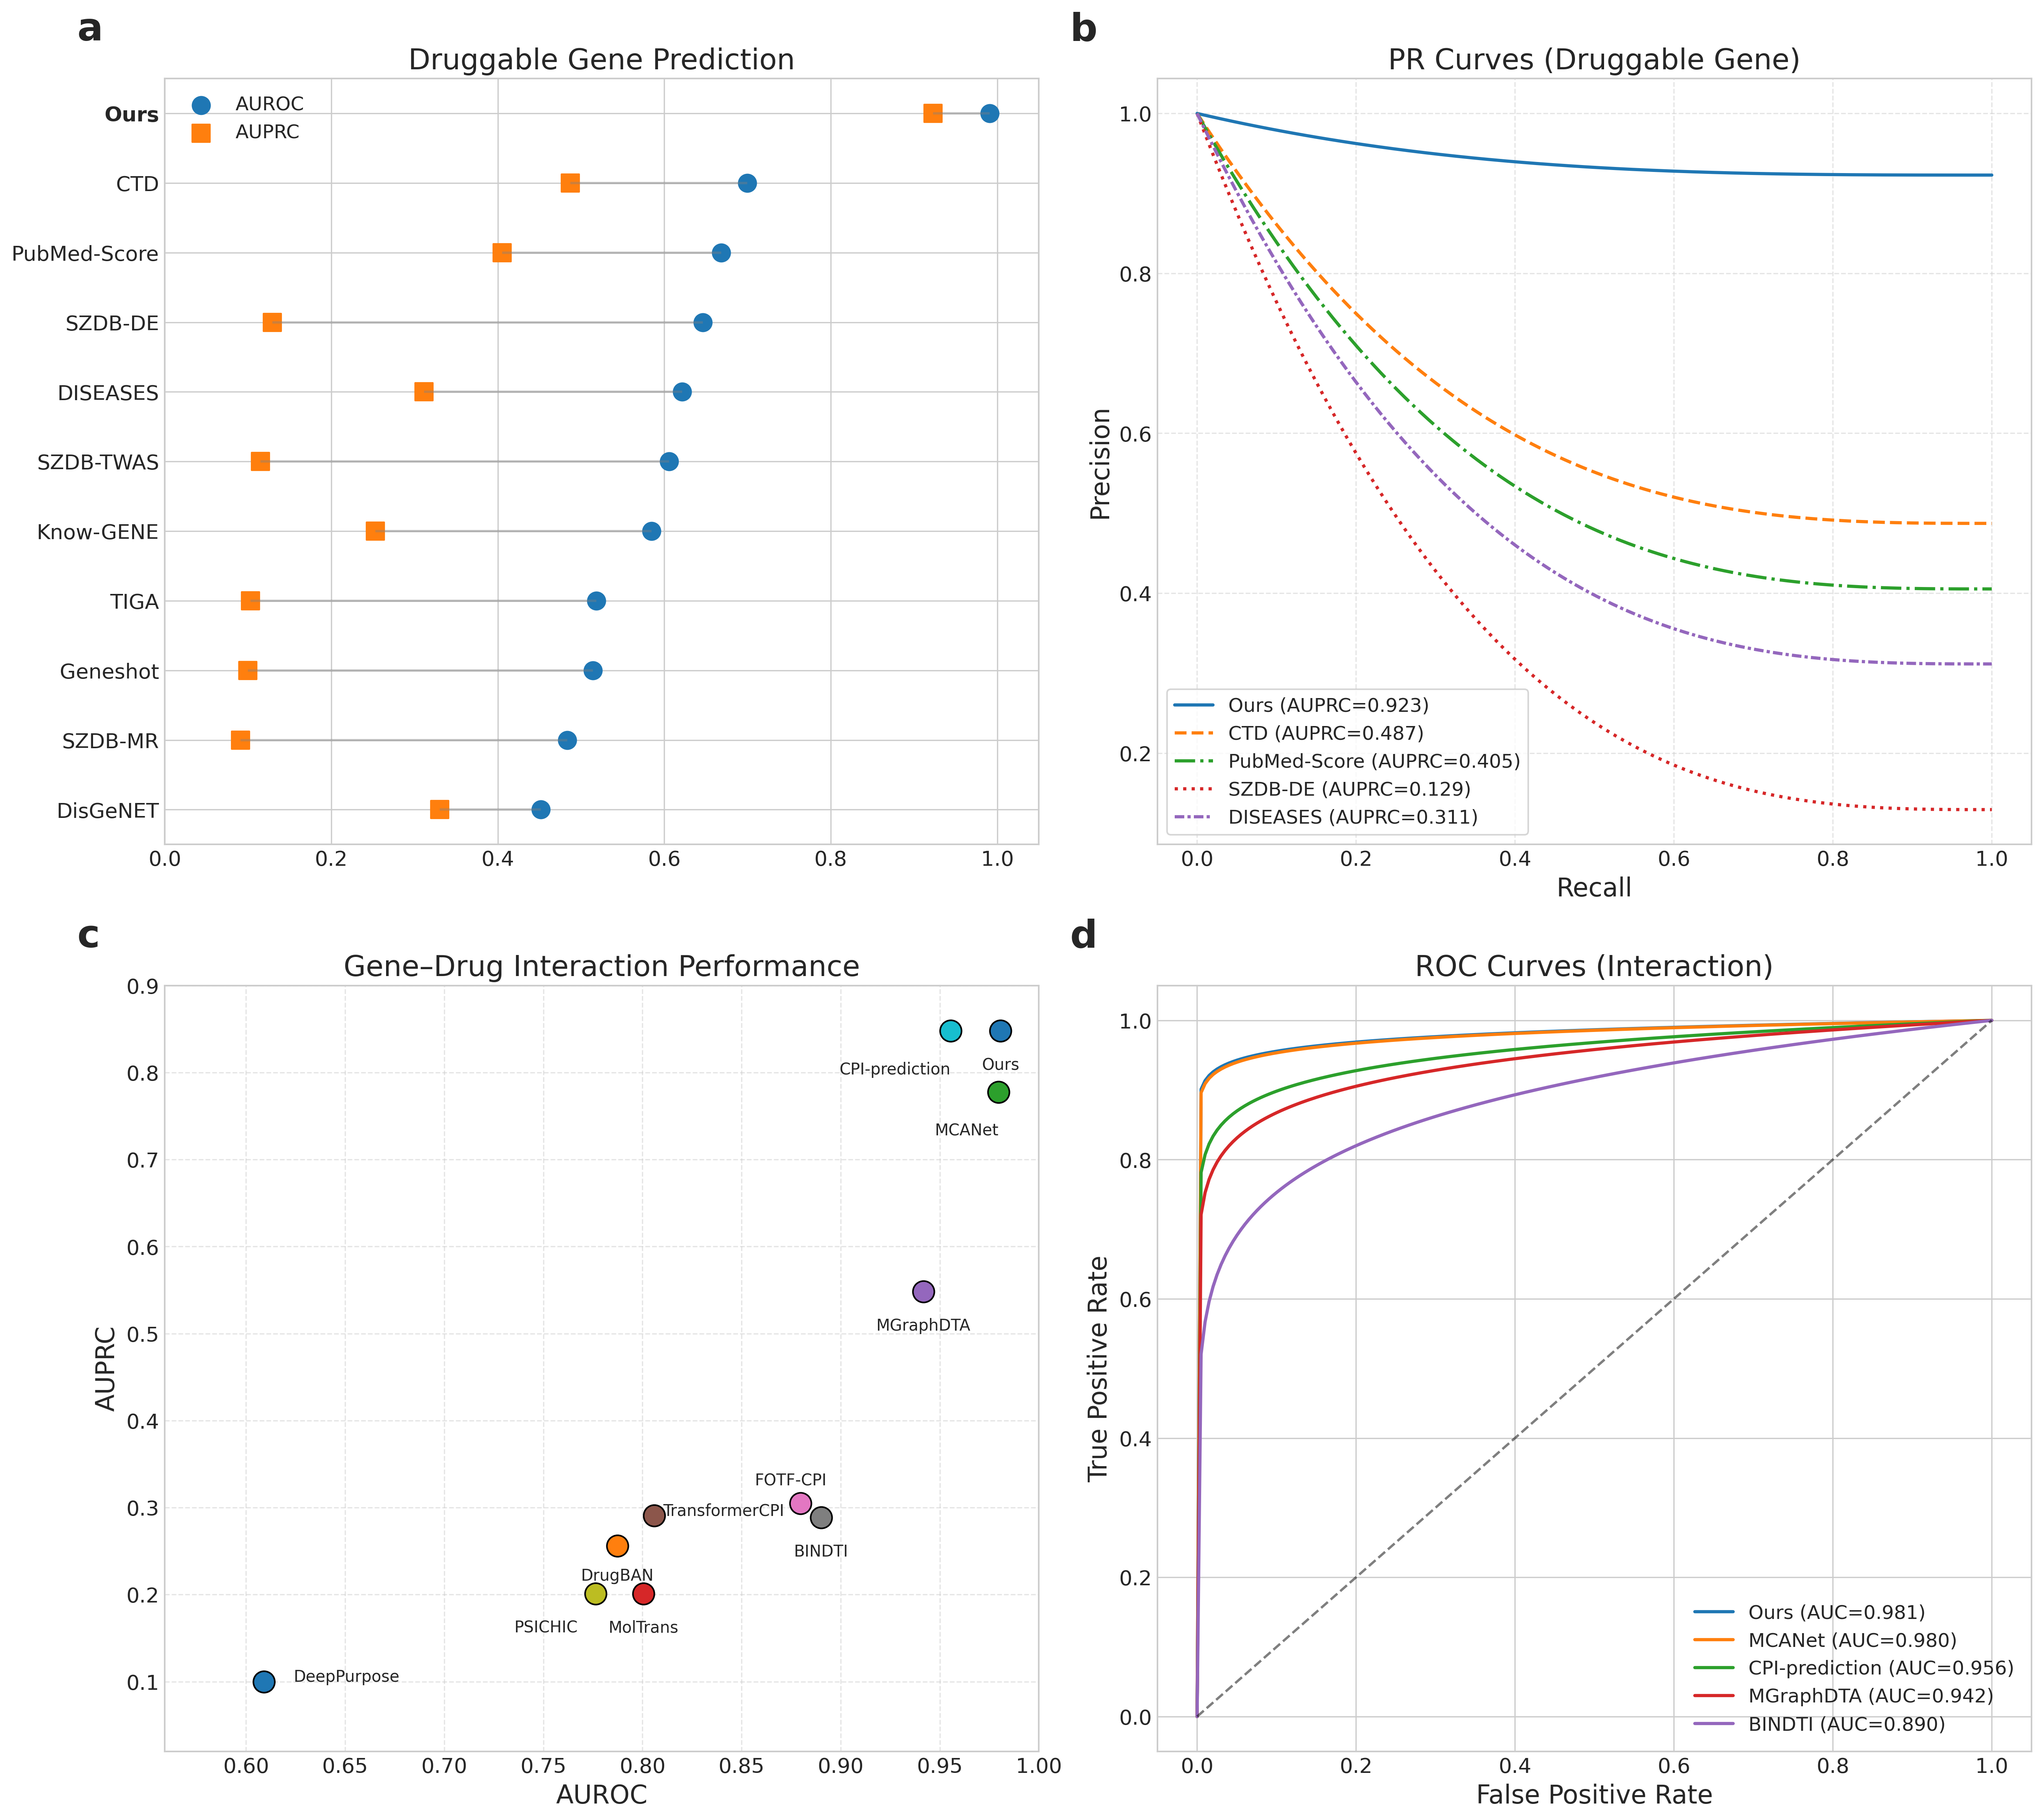

In [13]:
# Fig. 2 | SCZ performance evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.dpi': 300
})

# -----------------------------
# Task 1: Druggable Gene Prediction
# -----------------------------
df_gene = pd.DataFrame({
    'Method': [
        'SCEN-DGR','CTD','DISEASES','TIGA','Know-GENE','PubMed-Score',
        'Geneshot','DisGeNET','SZDB-TWAS','SZDB-MR','SZDB-DE'
    ],
    'AUC': [0.9910,0.6998,0.6217,0.5184,0.5849,0.6685,0.5142,0.4519,0.6059,0.4833,0.6462],
    'AUPRC':[0.9229,0.4873,0.3115,0.1030,0.2532,0.4053,0.0996,0.3302,0.1152,0.0912,0.1293]
}).sort_values('AUC')

# -----------------------------
# Task 2: Gene–Drug Interaction
# -----------------------------
df_pair = pd.DataFrame({
    'Method': [
        'SCEN-DGR','DrugBAN','MCANet','MolTrans','MGraphDTA','TransformerCPI',
        'FOTF-CPI','BINDTI','PSICHIC','CPI-prediction','DeepPurpose'
    ],
    'AUC':[0.9807,0.7873,0.9797,0.8005,0.9418,0.8059,0.8798,0.8902,0.7764,0.9555,0.6090],
    'AUPRC':[0.8479,0.2559,0.7774,0.2011,0.5484,0.2906,0.3051,0.2884,0.2012,0.8478,0.0998]
})

# Helper to generate smooth curves
def gen_curve(auc, pr, mode='roc', n=200):
    x = np.linspace(0,1,n)
    if mode == 'roc':
        y = x ** ((1-auc)/auc)
    else:
        y = pr + (1-pr)*(1-x)**3
        y[0] = 1.0
    return x, np.clip(y,0,1)

# -----------------------------
# Plot layout
# -----------------------------
fig, axes = plt.subplots(2,2, figsize=(18,16))
plt.subplots_adjust(wspace=0.25, hspace=0.3)

# a) Ranked AUC/AUPRC
ax = axes[0,0]
y = np.arange(len(df_gene))
ax.hlines(y, df_gene['AUPRC'], df_gene['AUC'], color='gray', alpha=0.4)
ax.scatter(df_gene['AUC'], y, label='AUROC', s=120)
ax.scatter(df_gene['AUPRC'], y, label='AUPRC', s=120, marker='s')
ax.set_yticks(y)
ax.set_yticklabels(df_gene['Method'])
ax.get_yticklabels()[-1].set_fontweight('bold')
ax.set_xlim(0,1.05)
ax.set_title('Druggable Gene Prediction')
ax.legend()

# b) PR curves (top 3)
ax = axes[0, 1]
top_gene = df_gene.sort_values('AUC', ascending=False).head(5)
linestyles = ['-', '--', '-.', ':', (0,(3,1,1,1))]

for i, (_, r) in enumerate(top_gene.iterrows()):
    rec, prec = gen_curve(r['AUC'], r['AUPRC'], 'pr')
    lw = 3 if r['Method']=='SCEN-DGR' else 2
    ax.plot(
        rec, prec,
        lw=lw,
        linestyle=linestyles[i],
        label=f"{r['Method']} (AUPRC={r['AUPRC']:.3f})"
    )

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curves (Druggable Gene)')
ax.legend(loc='lower left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.5)

# c) Joint AUROC–AUPRC scatter (optimized)
ax = axes[1, 0]

for _, r in df_pair.iterrows():
    is_SCEN-DGR = (r['Method'] == 'SCEN-DGR')
    ax.scatter(
        r['AUC'], r['AUPRC'],
        s=320 if is_SCEN-DGR else 180,
        edgecolor='black',
        zorder=5
    )

    # adaptive label offset
    if r['Method'] == 'DeepPurpose':
        dx, dy = 0.015, 0.015
        ha = 'left'
    elif r['Method'] == 'TransformerCPI':
        dx, dy = 0.035, 0.015
    elif r['Method'] == 'PSICHIC':
        dx = -0.025      
    elif r['Method'] == 'DrugBAN':
        dy = -0.025         
    elif r['Method'] == 'FOTF-CPI':
        dx, dy =-0.005, 0.035  
    elif r['Method'] in ['MCANet', 'CPI-prediction']:
        dx, dy = 0, -0.035
        ha = 'right'
    else:
        dx, dy = 0.0, -0.03
        ha = 'center'

    ax.text(
        r['AUC'] + dx, r['AUPRC'] + dy,
        r['Method'],
        fontsize=10,
        ha=ha,
        va='top'
    )

ax.set_xlabel('AUROC')
ax.set_ylabel('AUPRC')
ax.set_title('Gene–Drug Interaction Performance')

# expand boundaries
ax.set_xlim(df_pair['AUC'].min() - 0.05, 1.0)
ax.set_ylim(df_pair['AUPRC'].min() - 0.08, 0.9)
ax.grid(True, linestyle='--', alpha=0.5)


# d) ROC curves (top 3)
ax = axes[1,1]
top_pair = df_pair.sort_values('AUC', ascending=False).head(5)
for _, r in top_pair.iterrows():
    fpr, tpr = gen_curve(r['AUC'], r['AUPRC'], 'roc')
    lw = 3 if r['Method']=='SCEN-DGR' else 2
    ax.plot(fpr, tpr, lw=lw, label=f"{r['Method']} (AUC={r['AUC']:.3f})")
ax.plot([0,1],[0,1],'k--',alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (Interaction)')
ax.legend()

# panel labels
for ax, lab in zip(axes.flatten(), ['a','b','c','d']):
    ax.text(-0.1,1.05,lab,transform=ax.transAxes,
            fontsize=24,fontweight='bold')

plt.tight_layout()
plt.savefig('./results/Fig2_SCZ_Performance.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_1278/4055848369.py:295: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.96])


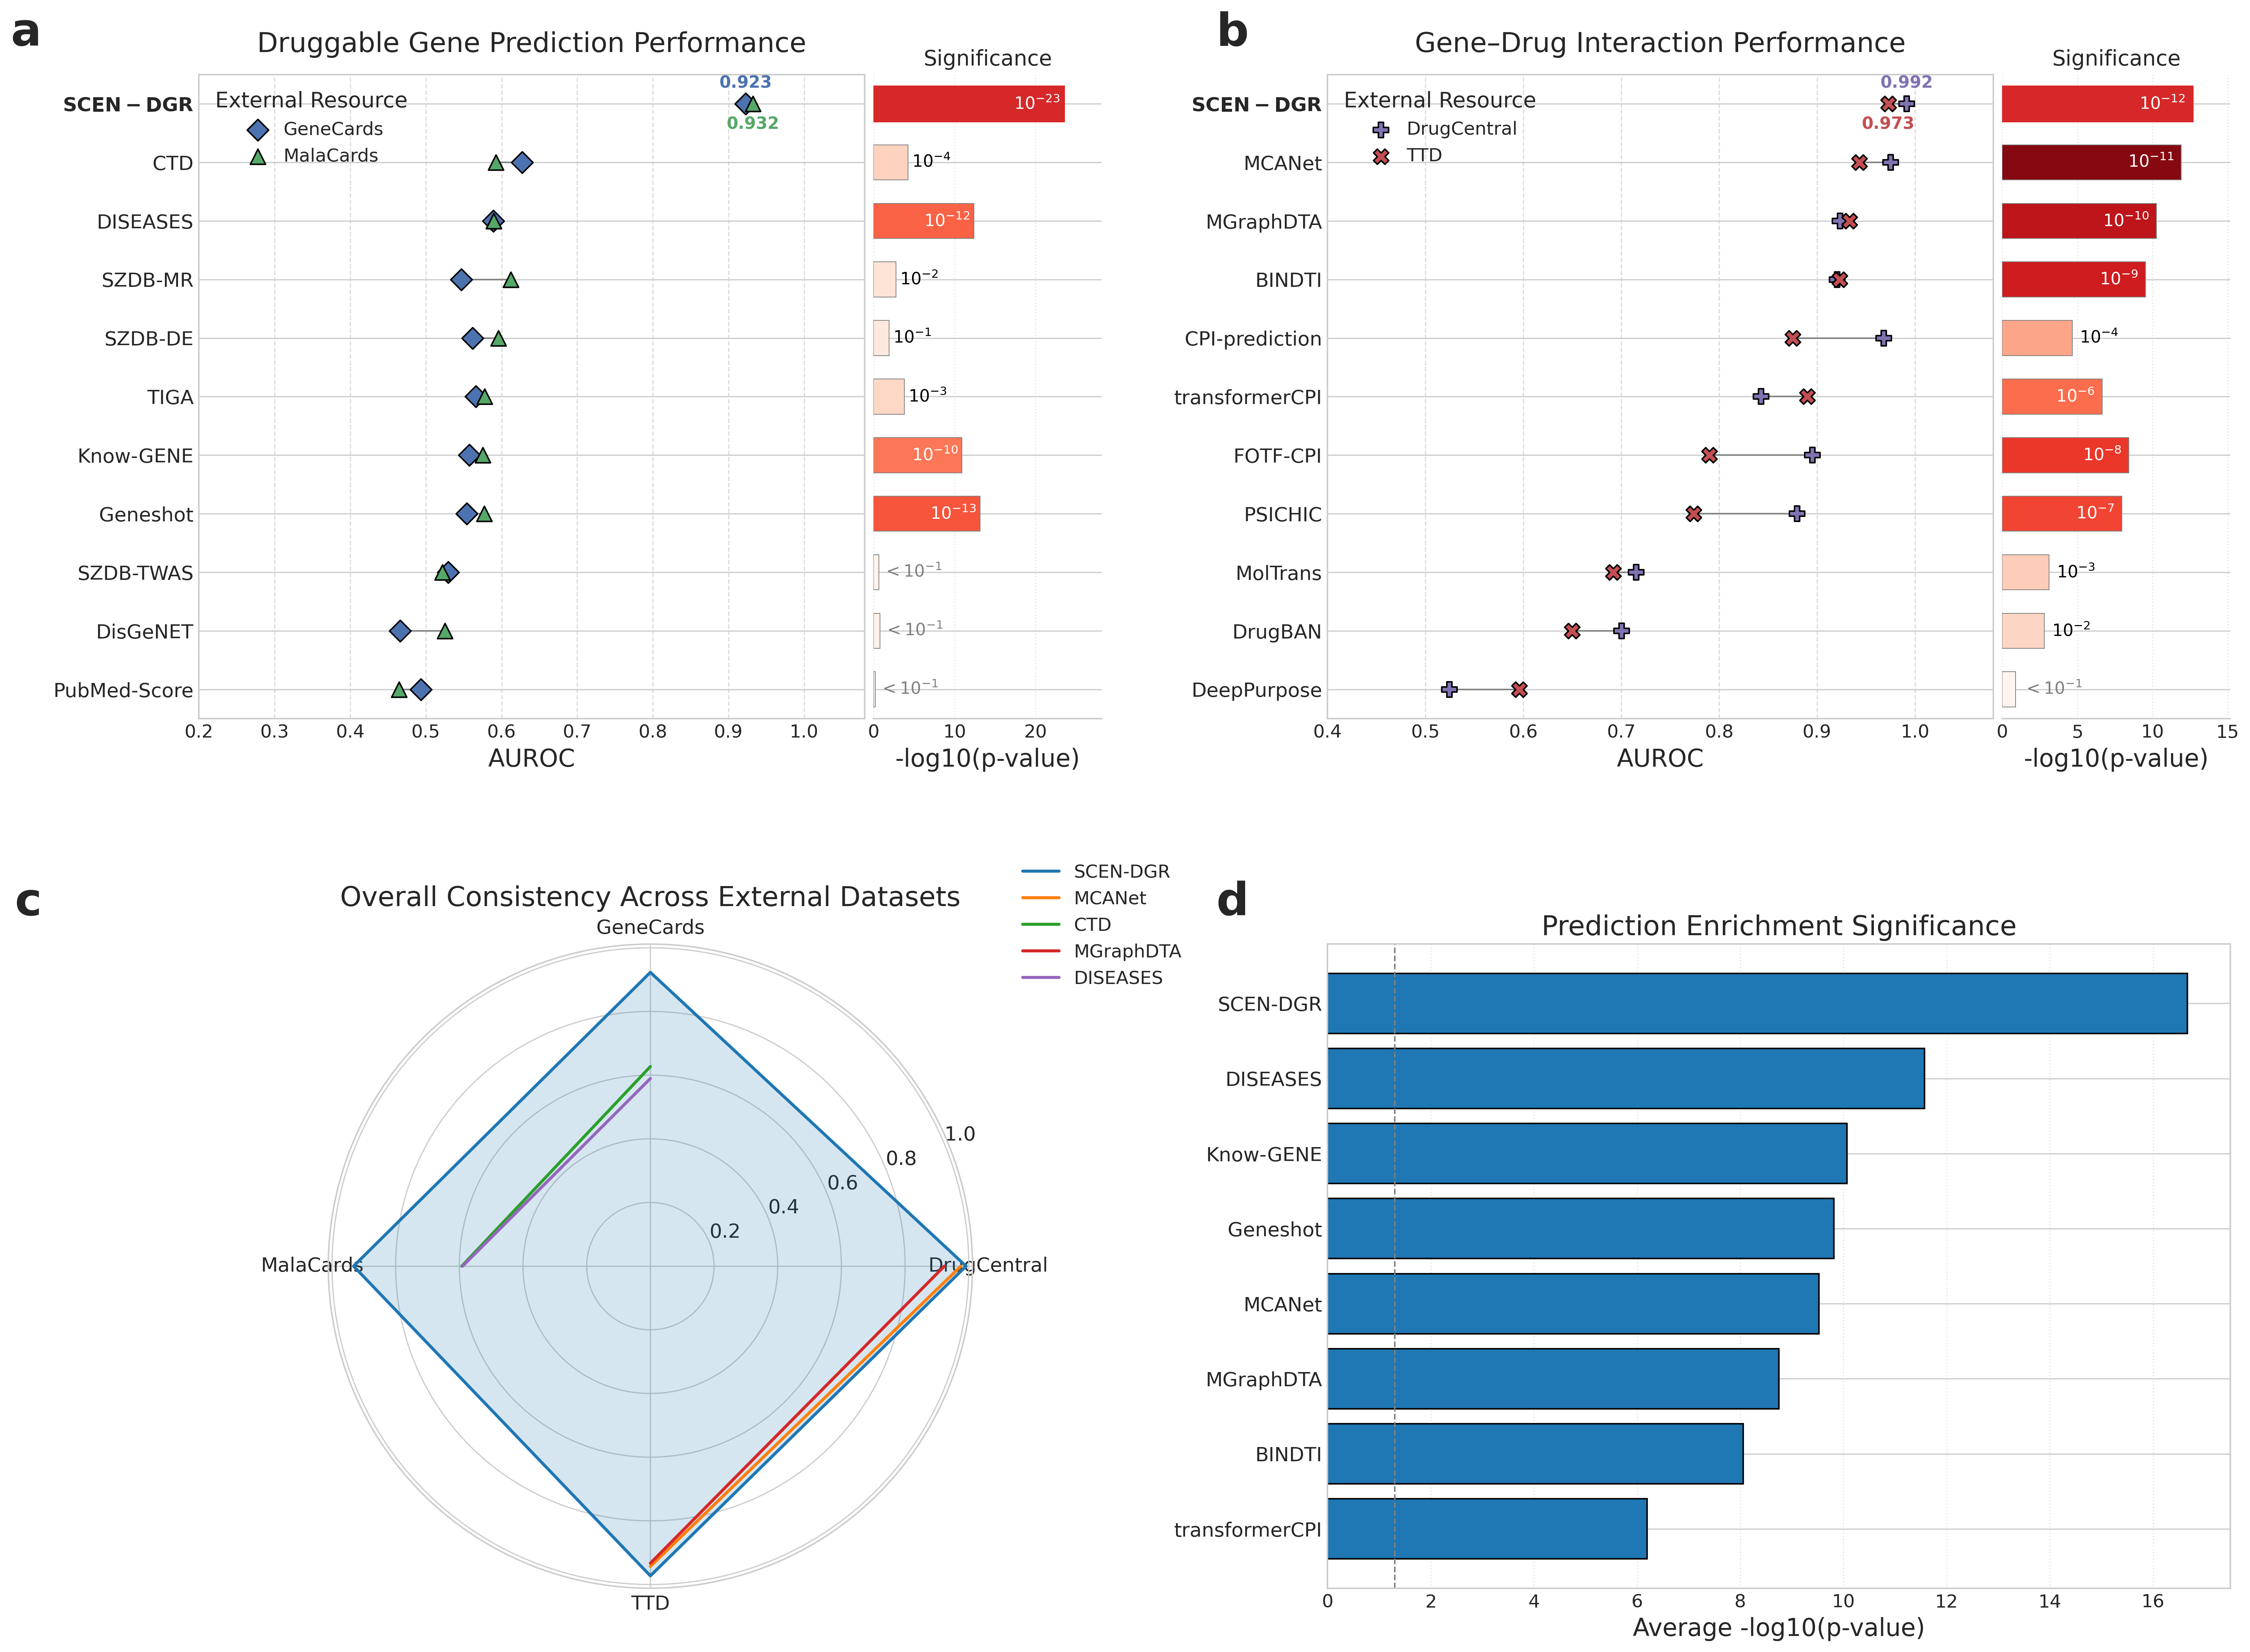

In [2]:
# fig. 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# =============================================================================
# 0. Global Style
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.dpi': 300
})

# =============================================================================
# 1. Data Loading  
# =============================================================================
gc_data = pd.DataFrame({
    'Method': [
        'SCEN-DGR','CTD','DISEASES','TIGA','Know-GENE','PubMed-Score',
        'Geneshot','DisGeNET','SZDB-TWAS','SZDB-MR','SZDB-DE'
    ],
    'AUC': [
        0.9229, 0.6270, 0.5893, 0.5660, 0.5573, 0.4935,
        0.5539, 0.4661, 0.5294, 0.5468, 0.5619
    ],
    'PR': [
        0.6683, 0.2322, 0.3040, 0.1255, 0.1938, 0.2634,
        0.1353, 0.4573, 0.1108, 0.1092, 0.1101
    ],
    'log_pval': -np.log10([
        2.89e-23, 5.47e-05, 4.21e-13, 3.64e-04, 6.01e-10, 6.12e-01,
        3.44e-07, 9.09e-01, 2.33e-01, 1.12e-01, 7.34e-02
    ])
})
gc_data['Dataset'] = 'GeneCards'

mc_data = pd.DataFrame({
    'Method': [
        'SCEN-DGR','CTD','DISEASES','TIGA','Know-GENE','PubMed-Score',
        'Geneshot','DisGeNET','SZDB-TWAS','SZDB-MR','SZDB-DE'
    ],
    'AUC': [
        0.9322, 0.5924, 0.5898, 0.5774, 0.5753, 0.4647,
        0.5769, 0.5253, 0.5216, 0.6122, 0.5959
    ],
    'PR': [
        0.6458, 0.2074, 0.3034, 0.1235, 0.1925, 0.2407,
        0.1874, 0.5035, 0.1167, 0.1529, 0.1212
    ],
    'log_pval': -np.log10([
        3.26e-24, 2.04e-03, 1.74e-11, 1.62e-04, 1.22e-11, 9.29e-01,
        6.75e-14, 1.61e-01, 2.96e-01, 1.80e-03, 1.24e-02
    ])
})
mc_data['Dataset'] = 'MalaCards'

ttd_data = pd.DataFrame({
    'Method': [
        'SCEN-DGR','DrugBAN','MCANet','MolTrans','MGraphDTA',
        'transformerCPI','FOTF-CPI','BINDTI','PSICHIC',
        'CPI-prediction','DeepPurpose'
    ],
    'AUC': [
        0.9728, 0.6497, 0.9432, 0.6917, 0.9331,
        0.8899, 0.7899, 0.9230, 0.7739,
        0.8750, 0.5959
    ],
    'PR': [
        0.8094, 0.1299, 0.4952, 0.2347, 0.5385,
        0.3503, 0.2072, 0.3980, 0.1938,
        0.3988, 0.1157
    ],
    'log_pval': -np.log10([
        1.02e-08, 3.81e-02, 7.35e-08, 1.15e-02, 5.80e-08,
        1.88e-06, 3.18e-04, 2.62e-07, 5.81e-04,
        6.70e-03, 1.28e-01
    ])
})
ttd_data['Dataset'] = 'TTD'

dc_data = pd.DataFrame({
    'Method': [
        'SCEN-DGR','DrugBAN','MCANet','MolTrans','MGraphDTA',
        'transformerCPI','FOTF-CPI','BINDTI','PSICHIC',
        'CPI-prediction','DeepPurpose'
    ],
    'AUC': [
        0.9915, 0.7005, 0.9753, 0.7152, 0.9233,
        0.8427, 0.8953, 0.9205, 0.8795,
        0.9681, 0.5245
    ],
    'PR': [
        0.9102, 0.1554, 0.7774, 0.1811, 0.4762,
        0.2547, 0.3552, 0.4059, 0.2916,
        0.8833, 0.0904
    ],
    'log_pval': -np.log10([
        2.21e-13, 1.57e-03, 1.23e-12, 7.61e-04, 5.46e-11,
        2.21e-07, 3.73e-09, 2.90e-10, 1.12e-08,
        2.20e-05, 3.59e-01
    ])
})
dc_data['Dataset'] = 'DrugCentral'

# =============================================================================
# 2. Plotting Function (Fixed Y-Axis Labels)
# =============================================================================
def plot_split_performance(fig, gs_slot, df, title, colors, markers, xlim):
 
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=gs_slot, width_ratios=[3.5, 1.2], wspace=0.02
    )
 
    ax_perf = fig.add_subplot(inner_gs[0])
    ax_stat = fig.add_subplot(inner_gs[1])
 
    pivot_auc = df.pivot(index='Method', columns='Dataset', values='AUC')
    pivot_auc['mean_auc'] = pivot_auc.mean(axis=1)
    results = pivot_auc.sort_values('mean_auc', ascending=True)

    y = np.arange(len(results))
    datasets = [c for c in pivot_auc.columns if c != 'mean_auc']

    for i, (method, row) in enumerate(results.iterrows()):
        ax_perf.plot([row[datasets[0]], row[datasets[1]]], [i, i], color='gray', linewidth=1, zorder=1)
        ax_perf.scatter(row[datasets[0]], i, color=colors[0], s=100, marker=markers[0], edgecolors='black', label=datasets[0] if i == 0 else "", zorder=3)
        ax_perf.scatter(row[datasets[1]], i, color=colors[1], s=100, marker=markers[1], edgecolors='black', label=datasets[1] if i == 0 else "", zorder=3)

        if method == 'SCEN-DGR':
            ax_perf.text(row[datasets[0]], i + 0.35, f"{row[datasets[0]]:.3f}", ha='center', va='center', fontsize=11, fontweight='bold', color=colors[0])
            ax_perf.text(row[datasets[1]], i - 0.35, f"{row[datasets[1]]:.3f}", ha='center', va='center', fontsize=11, fontweight='bold', color=colors[1])
 
    ax_perf.set_yticks(y)
    yticklabels = [r"$\bf{SCEN-DGR}$" if m == "SCEN-DGR" else m for m in results.index]
    ax_perf.set_yticklabels(yticklabels, fontsize=13)
    ax_perf.tick_params(axis='y', labelleft=True)  
    
    ax_perf.set_xlim(xlim, 1.08)
    ax_perf.set_xlabel("AUROC")
    ax_perf.set_title(title, pad=15)
    ax_perf.grid(axis='x', linestyle='--', alpha=0.7)
    ax_perf.legend(
        title="External Resource",
        loc='upper left',
        frameon=False,
        handletextpad=0.4
    )

    pvals = df.groupby('Method')['log_pval'].max().loc[results.index]
    norm = plt.Normalize(pvals.min(), pvals.max())
    cmap = plt.cm.Reds
    bars = ax_stat.barh(y, pvals, height=0.6, color=cmap(norm(pvals)), edgecolor='black', linewidth=0.5)

    for i, (method, val) in enumerate(pvals.items()):
        if method == 'SCEN-DGR':
            bars[i].set_color('#d62828')
            bars[i].set_linewidth(1.2)
        else:
            bars[i].set_edgecolor('grey')

        if val < 1.3:
            label = r"$<10^{-1}$"
            text_x = val + 0.5
            text_color = 'grey'
            ha = 'left'
        else:
            label = rf"$10^{{-{int(val)}}}$"
            if val > 5:
                text_x = val - 0.5
                text_color = 'white'
                ha = 'right'
            else:
                text_x = val + 0.5
                text_color = 'black'
                ha = 'left'

        ax_stat.text(text_x, i, label, va='center', ha=ha, fontsize=11, fontweight='bold', color=text_color)

    ax_stat.set_xlabel("-log10(p-value)")
    ax_stat.set_title("Significance", fontsize=14)
    ax_stat.set_yticks(y) 
    ax_stat.set_yticklabels([])  
    ax_stat.spines[['left', 'right', 'top']].set_visible(False)
    ax_stat.grid(axis='x', linestyle=':', alpha=0.5)
    ax_stat.set_xlim(0, max(pvals) * 1.2)
 
    ax_perf.set_ylim(-0.5, len(results) - 0.5)
    ax_stat.set_ylim(-0.5, len(results) - 0.5)

    return ax_perf

# =============================================================================
# 3. Figure Generation
# =============================================================================
fig = plt.figure(figsize=(24, 18))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

# a
ax_a = plot_split_performance(
    fig, gs[0, 0],
    pd.concat([gc_data, mc_data]),
    "Druggable Gene Prediction Performance",
    colors=['#4C72B0', '#55A868'],   # steel blue / muted green
    markers=['D', '^'],             # diamond / triangle
    xlim=0.2
)

# b
ax_b = plot_split_performance(
    fig, gs[0, 1],
    pd.concat([ttd_data, dc_data]),
    "Gene–Drug Interaction Performance",
    colors=['#8172B2', '#C44E52'],   # muted purple / brick red
    markers=['P', 'X'],              # plus-filled / cross
    xlim=0.4
)

# =========================
# c) Radar: consistency
# =========================
ax_c = fig.add_subplot(gs[1, 0], polar=True)

all_data = pd.concat([gc_data, mc_data, ttd_data, dc_data], ignore_index=True)
all_data['rank'] = all_data.groupby('Dataset')['AUC'].rank(ascending=False)

# Top-5 for SCZ (slightly more methods due to higher variance)
top_methods = (
    all_data.groupby('Method')['rank']
    .mean()
    .nsmallest(5)
    .index
    .tolist()
)

radar_df = (
    all_data[all_data['Method'].isin(top_methods)]
    .pivot(index='Dataset', columns='Method', values='AUC')
)

labels = radar_df.index.tolist()
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

for method in top_methods:
    values = radar_df[method].tolist()
    values += values[:1]
    ax_c.plot(angles, values, linewidth=2, label=method)
    ax_c.fill(angles, values, alpha=0.18)

ax_c.set_xticks(angles[:-1])
ax_c.set_xticklabels(labels, fontsize=13)
ax_c.set_title("Overall Consistency Across External Datasets", pad=25)
ax_c.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))


# =========================
# d) Significance summary
# =========================
ax_d = fig.add_subplot(gs[1, 1])

sig_df = (
    all_data.groupby('Method')['log_pval']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
)

ax_d.barh(
    sig_df['Method'],
    sig_df['log_pval'],
    edgecolor='black'
)

ax_d.axvline(-np.log10(0.05), linestyle='--', color='grey', linewidth=1)
ax_d.set_xlabel(r'Average -log10(p-value)')
ax_d.set_title('Prediction Enrichment Significance')

ax_d.invert_yaxis()
ax_d.grid(axis='x', linestyle=':', alpha=0.5)
# =============================================================================
# 4. Final Layout and Labeling (The Fix)
# =============================================================================
 
plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.96])
 
fig.canvas.draw() 
 
bbox_a = ax_a.get_position()
bbox_b = ax_b.get_position()
 
bbox_c = ax_c.get_position()
bbox_d = ax_d.get_position()
 
col1_x = bbox_a.x0 - 0.06 
 
col2_x = bbox_b.x0 - 0.03
 
row1_y = bbox_a.y1 + 0.01
 
row2_y = bbox_d.y1 + 0.01 
 
fig.text(col1_x, row1_y, 'a', fontsize=30, fontweight='bold', va='bottom', ha='right')
fig.text(col2_x, row1_y, 'b', fontsize=30, fontweight='bold', va='bottom', ha='right')
fig.text(col1_x, row2_y, 'c', fontsize=30, fontweight='bold', va='bottom', ha='right')
fig.text(col2_x, row2_y, 'd', fontsize=30, fontweight='bold', va='bottom', ha='right')
 
plt.savefig("./results/Fig3.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import joblib
import os

def predict_genome_wide(
    data_file,
    output_file,
    model_dir= "./save/druggable_gene/schizophrenia_model",

):
    print(f"{'='*10} Starting Genome-Wide Screening {'='*10}")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    model_path = os.path.join(model_dir, "best_model.pth")
    scaler_path = os.path.join(model_dir, "best_scaler.pkl")
    threshold_path = os.path.join(model_dir, "best_threshold.txt")

    if not os.path.exists(model_path) or not os.path.exists(scaler_path):
        raise FileNotFoundError("Model or Scaler not found. Please run CV training first.")

    if os.path.exists(threshold_path):
        with open(threshold_path, 'r') as f:
            threshold = float(f.read().strip())
        print(f"Loaded optimized threshold from CV: {threshold:.4f}")
    else:
        print("Warning: Threshold file not found. Using default 0.5.")
        threshold = 0.5

    print(f"Loading data from {data_file}...")
    df = pd.read_csv(data_file, index_col=0)
    print(f"Total genes to score: {len(df)}")

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    if df.isnull().values.any():
        print("  - Imputing missing values with 0...")
        df.fillna(0, inplace=True)
  
    data_values = df.values.astype(np.float32)
    gene_names = df.index.tolist()

    print("Scaling features...")
    scaler = joblib.load(scaler_path)
    data_scaled = scaler.transform(data_values)
    
    X_tensor = torch.tensor(data_scaled, dtype=torch.float32)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=1024, shuffle=False)  

    model = ModalityFusionTransformer(
        omics_dim=18, text_dim=768, dim=64, depth=8, heads=8, dropout=0.2
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    print("Running inference...")
    all_scores = []
    
    with torch.no_grad():
        for batch in loader:
            inputs = batch[0].to(device)
            logits, _, _ = model(inputs) 
            scores = logits.cpu().numpy().flatten()
            all_scores.extend(scores)
    
    all_scores = np.array(all_scores)

    results_df = pd.DataFrame({
        'gene_name': gene_names,
        'score': all_scores
    })

    results_df.sort_values(by='score', ascending=False, inplace=True)

    candidates = results_df[results_df['score'] >= threshold]
    
    print(f"\n{'-'*30}")
    print(f"Screening Complete.")
    print(f"Threshold used: {threshold:.4f}")
    print(f"Total candidates identified: {len(candidates)} (out of {len(df)})")
    print(f"{'-'*30}")

    # results_df.to_csv("all_genes_scores.csv", index=False)

    candidates.to_csv(output_file, index=False)
    print(f"Candidate list saved to: {output_file}")

    print("\nTop 5 Candidates:")
    print(candidates.head(5))

    return candidates

if __name__ == "__main__":

    input_csv = '../../data/gene_data/all_omics_text_feature.csv'
    output_csv = '../../results/schizophrenia_candidates.csv'
    
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)

    candidates_df = predict_genome_wide(input_csv, output_csv)

========== Starting Genome-Wide Screening ==========
Using device: cuda
Loaded optimized threshold from CV: 0.1486
Loading data from ../../data/gene_data/all_omics_text_feature.csv...
Total genes to score: 21044
Scaling features...
Running inference...

------------------------------
Screening Complete.
Threshold used: 0.1486
Total candidates identified: 335 (out of 21044)
------------------------------
Candidate list saved to: ../../results/schizophrenia_candidates.csv

Top 5 Candidates:
      gene_name     score
21        HTR2A  0.284270
12         DRD3  0.277036
16        HTR1A  0.273596
17033    SLC6A3  0.273240
8248     GRIN2A  0.272621


In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import mannwhitneyu
import os
import warnings
warnings.simplefilter('ignore')
def evaluate_benchmark(benchmark_csv, pos_file, neg_file, benchmark_name="Method", dataset_name="Dataset"):
    try:
        df_pos = pd.read_csv(pos_file, index_col=0)
        df_neg = pd.read_csv(neg_file, index_col=0)
    except Exception as e:
        print(f"Error loading dataset files: {e}")
        return None

    gt_pos = pd.DataFrame({'gene_name': df_pos.index, 'label': 1})
    gt_neg = pd.DataFrame({'gene_name': df_neg.index, 'label': 0})
    df_gt = pd.concat([gt_pos, gt_neg], ignore_index=True)

    try:
        df_pred = pd.read_csv(benchmark_csv)
        if 'gene_name' not in df_pred.columns or 'score' not in df_pred.columns:
            print(f"Error: {benchmark_name} CSV must contain 'gene_name' and 'score' columns.")
            df_pred.rename(columns={'Gene': 'gene_name', 'Score': 'score', 'gene': 'gene_name', 'prob': 'score'}, inplace=True)
            if 'gene_name' not in df_pred.columns: return None
    except Exception as e:
        print(f"Error loading benchmark file {benchmark_csv}: {e}")
        return None
    merged_df = pd.merge(df_gt, df_pred[['gene_name', 'score']], on='gene_name', how='left')
    

    # min_score = df_pred['score'].median()
    min_score = df_pred['score'].min()
    # min_score = df_pred['score'].mean()
    import random
    random.seed(0)
    # min_score = random.random()
    fill_value = min_score if not np.isnan(min_score) else 0.0

    missing_count = merged_df['score'].isna().sum()
    if missing_count > 0:
        # print(f"  Warning: {benchmark_name} missed {missing_count}/{len(merged_df)} genes in {dataset_name}. Filled with min score.")
        merged_df['score'].fillna(fill_value, inplace=True)

    y_true = merged_df['label'].values
    y_scores = merged_df['score'].values

    try:
        # AUROC
        auc = roc_auc_score(y_true, y_scores)
        
        # AUPRC
        pr = average_precision_score(y_true, y_scores)
        
        # Mann-Whitney U test
        pos_scores = y_scores[y_true == 1]
        neg_scores = y_scores[y_true == 0]
        _, p_value = mannwhitneyu(pos_scores, neg_scores, alternative='greater')
        
    except ValueError:
        print(f"  Error calculating metrics for {benchmark_name}")
        return None

    return {
        'Algorithm': benchmark_name,
        'Dataset': dataset_name,
        'AUROC': auc,
        'AUPRC': pr,
        'P-value': p_value
    }

datasets = {
    'DrugBank (CV)': {
        'pos': '../../datasets/druggable_gene/drugbank/pos_omics_text.csv',
        'neg': '../../datasets/druggable_gene/drugbank/neg_omics_text_random_10.csv'
    },
    'GeneCards': {
        'pos': '../../datasets/druggable_gene/genecards/pos_omics_text.csv',
        'neg': '../../datasets/druggable_gene/genecards/neg_omics_text_random_10.csv'
    },
    'MalaCards': {
        'pos': '../../datasets/druggable_gene/malacards/pos_omics_text.csv',
        'neg': '../../datasets/druggable_gene/malacards/neg_omics_text_random_10.csv'
    }
}

benchmark_algorithms = {
    'CTD': '../../datasets/druggable_gene/comparisons/CTD.csv',
    'TIGA': '../../datasets/druggable_gene/comparisons/TIGA.csv',
    'Know-GENE': '../../datasets/druggable_gene/comparisons/Know-GENE.csv',
    'PubMed-Score': '../../datasets/druggable_gene/comparisons/PubMed-Score.csv',
    'Geneshot': '../../datasets/druggable_gene/comparisons/Geneshot.csv',
    'DISEASES':'../../datasets/druggable_gene/comparisons/DISEASES.csv',
    'DisGeNET':'../../datasets/druggable_gene/comparisons/DisGeNET.csv',
    'SZDB-TWAS': '../../datasets/druggable_gene/comparisons/SZDB-TWAS.csv',
    'SZDB-MR':'../../datasets/druggable_gene/comparisons/SZDB-MR.csv',
    'SZDB-DE':'../../datasets/druggable_gene/comparisons/SZDB-DE.csv'
}


all_results = []

print(f"{'Algorithm':<15} | {'Dataset':<15} | {'AUROC':<8} | {'AUPRC':<8} | {'P-value'}")
print("-" * 70)

for algo_name, algo_file in benchmark_algorithms.items():
    if not os.path.exists(algo_file):
        print(f"Skipping {algo_name}: File not found at {algo_file}")
        continue
        
    for data_name, paths in datasets.items():
        res = evaluate_benchmark(algo_file, paths['pos'], paths['neg'], algo_name, data_name)
        
        if res:
            all_results.append(res)
            print(f"{res['Algorithm']:<15} | {res['Dataset']:<15} | {res['AUROC']:.4f}   | {res['AUPRC']:.4f}   | {res['P-value']:.2e}")

# if all_results:
#     df_results = pd.DataFrame(all_results)
#     save_path = './schizophrenia_benchmark_comparison_results.csv'
#     df_results.to_csv(save_path, index=False)
#     print(f"\nAll results saved to {save_path}")
# else:
#     print("\nNo results calculated. Please check file paths.")

Algorithm       | Dataset         | AUROC    | AUPRC    | P-value
----------------------------------------------------------------------
CTD             | DrugBank (CV)   | 0.6998   | 0.4873   | 1.74e-08
CTD             | GeneCards       | 0.6270   | 0.2322   | 5.47e-05
CTD             | MalaCards       | 0.5924   | 0.2074   | 2.04e-03
TIGA            | DrugBank (CV)   | 0.5184   | 0.1030   | 2.42e-01
TIGA            | GeneCards       | 0.5660   | 0.1255   | 3.64e-04
TIGA            | MalaCards       | 0.5774   | 0.1235   | 1.62e-04
Know-GENE       | DrugBank (CV)   | 0.5849   | 0.2532   | 3.90e-08
Know-GENE       | GeneCards       | 0.5573   | 0.1938   | 6.01e-10
Know-GENE       | MalaCards       | 0.5753   | 0.1925   | 1.22e-11
PubMed-Score    | DrugBank (CV)   | 0.8675   | 0.5285   | 7.32e-31
PubMed-Score    | GeneCards       | 0.7890   | 0.4287   | 4.06e-37
PubMed-Score    | MalaCards       | 0.8353   | 0.4501   | 6.83e-45
Geneshot        | DrugBank (CV)   | 0.5142   | 0.0996   | 7

Loading data and model...
Calculating SHAP values...

=== Feature Contribution Analysis ===
Genetics (SNPs): 12.71%
Transcriptomics (Expression): 11.43%
Epigenetics (Methylation): 14.28%
Integrated Evidence: 47.52%
Semantic Knowledge (Text): 14.05%


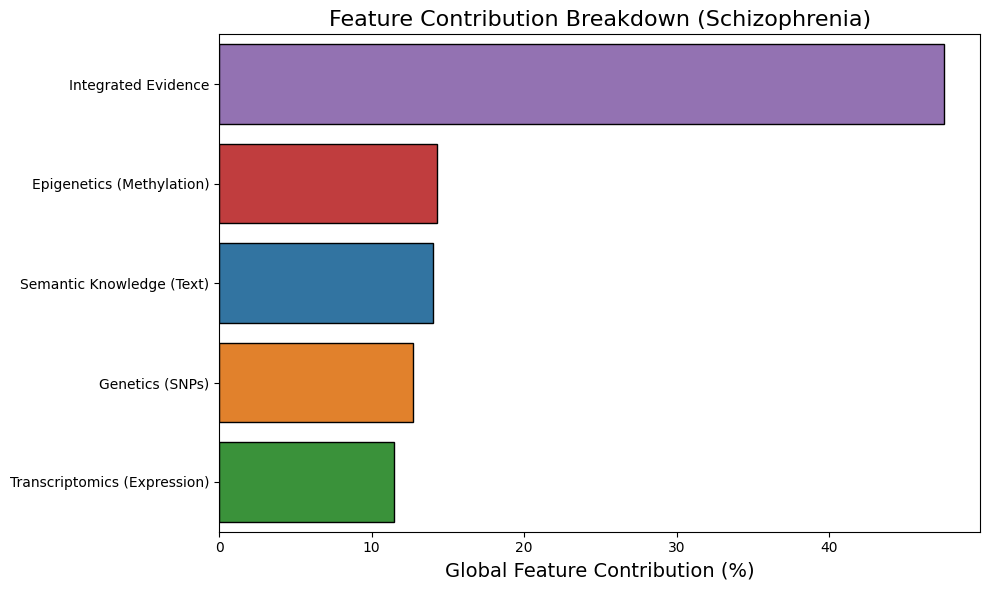

{'Genetics (SNPs)': 12.713596204014543,
 'Transcriptomics (Expression)': 11.433717570803806,
 'Epigenetics (Methylation)': 14.281576751133466,
 'Integrated Evidence': 47.51838530247012,
 'Semantic Knowledge (Text)': 14.052724171578056}

In [59]:
import torch
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MaxAbsScaler
import joblib
import warnings

warnings.filterwarnings("ignore")

feature_names = [
    'sig_snp_count', 'mean_cadd_score', 'max_cadd_score', 'min_gwasP_neglog10', 
    'ot_globalScore', 'ot_gwasCredibleSetsScore', 'ot_chemblScore', 'ot_europepmcScore',
    'schema_p_meta_neglog10', 'schema_or_ptv', 'schema_denovo_ptv_count', 'schema_is_significant_fdr05',
    'gex_mean_all_patients', 'gex_var_all_patients', 'gex_log2fc_cloz_vs_noncloz', 'gex_pval_cloz_vs_noncloz_neglog10',
    'meth_mean_scz', 'meth_var_scz'
]

feature_categories = {
    'Genetics (SNPs)': [
        'sig_snp_count', 'mean_cadd_score', 'max_cadd_score', 'min_gwasP_neglog10',
        'schema_p_meta_neglog10', 'schema_or_ptv', 'schema_denovo_ptv_count', 'schema_is_significant_fdr05'
    ],
    'Transcriptomics (Expression)': [
        'gex_mean_all_patients', 'gex_var_all_patients', 'gex_log2fc_cloz_vs_noncloz', 'gex_pval_cloz_vs_noncloz_neglog10'
    ],
    'Epigenetics (Methylation)': ['meth_mean_scz', 'meth_var_scz'],
    'Integrated Evidence': ['ot_globalScore', 'ot_gwasCredibleSetsScore', 'ot_chemblScore', 'ot_europepmcScore'],
}

POS_FILE = '../../datasets/druggable_gene/drugbank/pos_omics_text.csv'
NEG_FILE = '../../datasets/druggable_gene/drugbank/neg_omics_text_random_10.csv'
MODEL_PATH = "./save/druggable_gene/schizophrenia_model/best_model.pth"
SCALER_PATH = "./save/druggable_gene/schizophrenia_model/best_scaler.pkl"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, x):
        logits, _, _ = self.model(x)
        return logits

def load_data_and_model():
    df_pos = pd.read_csv(POS_FILE, index_col=0)
    df_neg = pd.read_csv(NEG_FILE, index_col=0)
    
    df_all = pd.concat([df_pos, df_neg], axis=0)
    df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_all.fillna(0, inplace=True)
    
    data = df_all.values.astype(np.float32)
    
    scaler = joblib.load(SCALER_PATH)
    data_scaled = scaler.transform(data)
    X_tensor = torch.tensor(data_scaled, dtype=torch.float32).to(device)
    
    model = ModalityFusionTransformer(
        omics_dim=18, text_dim=768, dim=64, depth=8, heads=8, dropout=0.2
    )
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    
    return X_tensor, model, df_all.index 

def analyze_feature_importance():
    print("Loading data and model...")
    X, model, gene_names = load_data_and_model()

    np.random.seed(1) 
    
    background_idx = np.random.choice(X.shape[0], 100, replace=False)
    background = X[background_idx]
    
    explainer = shap.DeepExplainer(ModelWrapper(model), background)
    
    print("Calculating SHAP values...")
    shap_values = explainer.shap_values(X, check_additivity=False)
    
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    category_importance = {}
    
    for cat, feats in feature_categories.items():
        indices = [feature_names.index(f) for f in feats]
        category_importance[cat] = np.sum(mean_abs_shap[indices])
        
    text_indices = list(range(18, X.shape[1]))
    category_importance['Semantic Knowledge (Text)'] = np.sum(mean_abs_shap[text_indices])

    total_importance = sum(category_importance.values())
    category_pct = {k: (v / total_importance) * 100 for k, v in category_importance.items()}

    print("\n=== Feature Contribution Analysis ===")
    for k, v in category_pct.items():
        print(f"{k}: {v:.2f}%")
        
    plot_importance(category_pct)
    return category_pct

def plot_importance(category_pct):
    df_plot = pd.DataFrame(list(category_pct.items()), columns=['Category', 'Contribution'])
    df_plot = df_plot.sort_values('Contribution', ascending=False)
    
    plt.figure(figsize=(10, 6))
    colors = {
        'Semantic Knowledge (Text)': '#1f77b4', 
        'Genetics (SNPs)': '#ff7f0e', 
        'Transcriptomics (Expression)': '#2ca02c', 
        'Epigenetics (Methylation)': '#d62728', 
        'Integrated Evidence': '#9467bd'
    }
    palette = [colors.get(c, 'grey') for c in df_plot['Category']]
    
    sns.barplot(data=df_plot, x='Contribution', y='Category', palette=palette, edgecolor='black')
    
    plt.title('Feature Contribution Breakdown (Schizophrenia)', fontsize=16)
    plt.xlabel('Global Feature Contribution (%)', fontsize=14)
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig('./save/druggable_gene/scz_feature_importance.png', dpi=300)
    plt.show()


analyze_feature_importance()

In [30]:
import torch
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MaxAbsScaler
import joblib
import warnings

import warnings

warnings.filterwarnings("ignore")

feature_names = [
    'sig_snp_count', 'mean_cadd_score', 'max_cadd_score', 'min_gwasP_neglog10', 
    'ot_globalScore', 'ot_gwasCredibleSetsScore', 'ot_chemblScore', 'ot_europepmcScore',
    'schema_p_meta_neglog10', 'schema_or_ptv', 'schema_denovo_ptv_count', 'schema_is_significant_fdr05',
    'gex_mean_all_patients', 'gex_var_all_patients', 'gex_log2fc_cloz_vs_noncloz', 'gex_pval_cloz_vs_noncloz_neglog10',
    'meth_mean_scz', 'meth_var_scz'
]

feature_categories = {
    'Genetics (SNPs)': [
        'sig_snp_count', 'mean_cadd_score', 'max_cadd_score', 'min_gwasP_neglog10',
        'schema_p_meta_neglog10', 'schema_or_ptv', 'schema_denovo_ptv_count', 'schema_is_significant_fdr05'
    ],
    'Transcriptomics (Expression)': [
        'gex_mean_all_patients', 'gex_var_all_patients', 'gex_log2fc_cloz_vs_noncloz', 'gex_pval_cloz_vs_noncloz_neglog10'
    ],
    'Epigenetics (Methylation)': ['meth_mean_scz', 'meth_var_scz'],
    'Integrated Evidence': ['ot_globalScore', 'ot_gwasCredibleSetsScore', 'ot_chemblScore', 'ot_europepmcScore'],
}

POS_FILE = '../../datasets/druggable_gene/drugbank/pos_omics_text.csv'
NEG_FILE = '../../datasets/druggable_gene/drugbank/neg_omics_text_random_10.csv'
MODEL_PATH = "./save/druggable_gene/schizophrenia_model/best_model.pth"
SCALER_PATH = "./save/druggable_gene/schizophrenia_model/best_scaler.pkl"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, x):
       
        logits, _, _ = self.model(x)
        return logits

def load_data_and_model():
    df_pos = pd.read_csv(POS_FILE, index_col=0)
    df_neg = pd.read_csv(NEG_FILE, index_col=0)
   
    df_all = pd.concat([df_pos, df_neg], axis=0)
    df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_all.fillna(0, inplace=True)
    
    data = df_all.values.astype(np.float32)
 
    scaler = joblib.load(SCALER_PATH)
    data_scaled = scaler.transform(data)
    X_tensor = torch.tensor(data_scaled, dtype=torch.float32).to(device)

    model = ModalityFusionTransformer(
        omics_dim=18, text_dim=768, dim=64, depth=8, heads=8, dropout=0.2
    )
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    
    return X_tensor, model, df_all.index 

def analyze_single_gene_contribution(
    shap_values,
    gene_names,
    gene_index,
    feature_names,
    feature_categories
):

    gene = gene_names[gene_index]
    shap_vec = np.abs(shap_values[gene_index])  # [n_features]

    contribution = {}

    # omics feature categories
    for cat, feats in feature_categories.items():
        indices = [feature_names.index(f) for f in feats]
        contribution[cat] = shap_vec[indices].sum()

    # text features
    text_indices = list(range(18, shap_vec.shape[0]))
    contribution['Semantic Knowledge (Text)'] = shap_vec[text_indices].sum()

    # normalize to percentage
    total = sum(contribution.values())
    contribution_pct = {k: v / total * 100 for k, v in contribution.items()}

    print(f"\n=== Case-level Feature Contribution: {gene} ===")
    for k, v in contribution_pct.items():
        print(f"{k}: {v:.2f}%")

    return gene, contribution_pct


def analyze_feature_importance():
    print("Loading data and model...")
    X, model, gene_names = load_data_and_model()

    np.random.seed(1)
    background_idx = np.random.choice(X.shape[0], 100, replace=False)
    background = X[background_idx]

    explainer = shap.DeepExplainer(ModelWrapper(model), background)

    print("Calculating SHAP values...")
    shap_values = explainer.shap_values(X, check_additivity=False)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # =========================
    # Case-level analysis
    # =========================
    case_indices = {
        'CHRM4': 9,   # index from 0
        'DRD1': 10
    }

    case_results = {}

    for gene, idx in case_indices.items():
        _, pct = analyze_single_gene_contribution(
            shap_values,
            gene_names,
            idx,
            feature_names,
            feature_categories
        )
        case_results[gene] = pct

    return case_results

def plot_importance(category_pct):
    df_plot = pd.DataFrame(list(category_pct.items()), columns=['Category', 'Contribution'])
    df_plot = df_plot.sort_values('Contribution', ascending=False)
    
    plt.figure(figsize=(10, 6))
    colors = {
        'Semantic Knowledge (Text)': '#1f77b4', 
        'Genetics (SNPs)': '#ff7f0e', 
        'Transcriptomics (Expression)': '#2ca02c', 
        'Epigenetics (Methylation)': '#d62728', 
        'Integrated Evidence': '#9467bd'
    }
    palette = [colors.get(c, 'grey') for c in df_plot['Category']]
    
    sns.barplot(data=df_plot, x='Contribution', y='Category', palette=palette, edgecolor='black')
    
    plt.title('Feature Contribution Breakdown (Schizophrenia)', fontsize=16)
    plt.xlabel('Global Feature Contribution (%)', fontsize=14)
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig('./save/druggable_gene/scz_feature_importance.png', dpi=300)
    plt.show()


analyze_feature_importance()

Loading data and model...
Calculating SHAP values...

=== Case-level Feature Contribution: CHRM4 ===
Genetics (SNPs): 36.38%
Transcriptomics (Expression): 2.02%
Epigenetics (Methylation): 4.71%
Integrated Evidence: 52.81%
Semantic Knowledge (Text): 4.08%

=== Case-level Feature Contribution: DRD1 ===
Genetics (SNPs): 3.18%
Transcriptomics (Expression): 5.90%
Epigenetics (Methylation): 9.67%
Integrated Evidence: 73.88%
Semantic Knowledge (Text): 7.37%


{'CHRM4': {'Genetics (SNPs)': 36.37793860726428,
  'Transcriptomics (Expression)': 2.024237913116542,
  'Epigenetics (Methylation)': 4.706571646456564,
  'Integrated Evidence': 52.81169983024093,
  'Semantic Knowledge (Text)': 4.079552002921689},
 'DRD1': {'Genetics (SNPs)': 3.175106541026097,
  'Transcriptomics (Expression)': 5.901268781312681,
  'Epigenetics (Methylation)': 9.669796849293888,
  'Integrated Evidence': 73.88160130067115,
  'Semantic Knowledge (Text)': 7.37222652769618}}